<a href="https://colab.research.google.com/github/YagoBaltazar/Linguagens-de-Programa-o/blob/main/qualidade_ar_brasil.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercício Prático — Análise de Qualidade do Ar
no Brasil com Python

##Contexto do Problema

A poluição do ar é um problema crescente em diversas cidades brasileiras. O Ministério do Meio Ambiente
deseja analisar dados coletados por sensores ambientais instalados em diferentes capitais para entender:
* quais cidades apresentam maior concentração de poluentes
* quais períodos do ano apresentam pior qualidade do ar
* quais poluentes são mais críticos

Você foi contratado como analista de dados para realizar uma análise exploratória inicial utilizando Python
e Pandas no Google Colab.

# Dataset

Arquivo: qualidade_ar_brasil.csv

##Estrutura da base

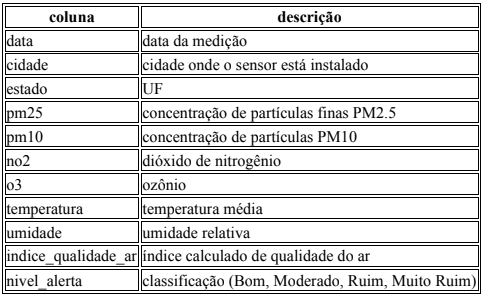

# Objetivos da atividade

O aluno deverá aprender a:
* carregar dados ambientais com Pandas
* realizar inspeção inicial do dataset
* aplicar filtros por cidade e nível de alerta
* calcular médias e rankings de poluentes
* identificar padrões temporais
* interpretar dados ambientais

# Parte 1 — Preparação do ambiente

In [13]:
import pandas as pd
#Carregue o dataset:
df = pd.read_csv('/content/qualidade_ar_brasil.csv')

# Parte 2 — Inspeção inicial do dataset

In [3]:
df.shape
df.head()
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   data                 800 non-null    object 
 1   cidade               800 non-null    object 
 2   estado               800 non-null    object 
 3   pm25                 800 non-null    float64
 4   pm10                 800 non-null    float64
 5   no2                  800 non-null    float64
 6   o3                   800 non-null    float64
 7   temperatura          800 non-null    float64
 8   umidade              800 non-null    float64
 9   indice_qualidade_ar  800 non-null    float64
 10  nivel_alerta         800 non-null    object 
dtypes: float64(7), object(4)
memory usage: 68.9+ KB


,0
data,0
cidade,0
estado,0
pm25,0
pm10,0
no2,0
o3,0
temperatura,0
umidade,0
indice_qualidade_ar,0


In [12]:
df = pd.read_csv('/content/qualidade_ar_brasil.csv')
df.shape
df['cidade'].nunique()
df.isnull().sum()

,0
data,0
cidade,0
estado,0
pm25,0
pm10,0
no2,0
o3,0
temperatura,0
umidade,0
indice_qualidade_ar,0


**Perguntas**

1. Quantas medições existem no dataset? 800 medições.
2. Quantas cidades estão presentes na base? 10 cidades: Belo Horizonte, Brasília, Curitiba, Fortaleza, Manaus, Porto Alegre, Recife, Rio de Janeiro, Salvador e São Paulo.
3. Quais colunas representam poluentes atmosféricos? pm25, pm10, no2 e o3.
4. Existem valores ausentes no dataset? Não. df.isnull().sum() retorna zero em todas as colunas

# Parte 3 — Análise por cidade

In [6]:
#Liste as cidades presentes no dataset:
df['cidade'].unique()
#Calcule a média de poluição por cidade:
df.groupby('cidade')[['pm25','pm10','no2','o3']].mean()

,pm25,pm10,no2,o3
cidade,,,,
Belo Horizonte,27.874026,48.409091,27.992208,30.141558
Brasília,31.351724,59.428736,29.926437,33.167816
Curitiba,25.339785,43.408602,26.151613,28.435484
Fortaleza,23.186250,44.662500,24.232500,34.176250
Manaus,26.271084,46.898795,22.566265,30.354217
Porto Alegre,26.798592,47.760563,27.959155,27.991549
Recife,23.416471,41.165882,24.320000,32.205882
Rio de Janeiro,27.825301,43.106024,30.925301,38.836145
Salvador,21.503896,39.102597,24.568831,34.274026


In [14]:
df.groupby('cidade')[['pm25','pm10','no2','o3']].mean()

,pm25,pm10,no2,o3
cidade,,,,
Belo Horizonte,27.874026,48.409091,27.992208,30.141558
Brasília,31.351724,59.428736,29.926437,33.167816
Curitiba,25.339785,43.408602,26.151613,28.435484
Fortaleza,23.186250,44.662500,24.232500,34.176250
Manaus,26.271084,46.898795,22.566265,30.354217
Porto Alegre,26.798592,47.760563,27.959155,27.991549
Recife,23.416471,41.165882,24.320000,32.205882
Rio de Janeiro,27.825301,43.106024,30.925301,38.836145
Salvador,21.503896,39.102597,24.568831,34.274026


**Perguntas**
1. Qual cidade apresenta maior média de PM2.5?São Paulo (33,7 µg/m³).
2. Qual cidade apresenta maior média de NO2? São Paulo também (39,3 µg/m³).
3. Existe alguma cidade com níveis consistentemente mais altos de poluentes? Sim, São Paulo. Ela aparece no topo do ranking de PM2.5 e NO2

# Parte 4 — Análise do índice de qualidade do ar

In [7]:
#Calcule a média do índice de qualidade do ar por cidade:
df.groupby('cidade')['indice_qualidade_ar'].mean().sort_values(ascending=False)

,indice_qualidade_ar
cidade,
São Paulo,59.345312
Brasília,54.955172
Rio de Janeiro,50.639759
Belo Horizonte,48.344156
Porto Alegre,46.898592
Manaus,45.092771
Fortaleza,44.646250
Curitiba,44.359140
Recife,43.198824


In [15]:
df.groupby('cidade')['indice_qualidade_ar'].mean().sort_values(ascending=False)

,indice_qualidade_ar
cidade,
São Paulo,59.345312
Brasília,54.955172
Rio de Janeiro,50.639759
Belo Horizonte,48.344156
Porto Alegre,46.898592
Manaus,45.092771
Fortaleza,44.646250
Curitiba,44.359140
Recife,43.198824


**Perguntas**
1. Qual cidade apresenta pior qualidade média do ar? São Paulo (IQA médio = 59,3).

2. Qual cidade apresenta melhor qualidade do ar? Salvador (IQA médio = 42,3).

# Parte 5 — Filtragem por nível de alerta

In [8]:
#Filtre apenas registros classificados como Ruim ou Muito Ruim.
df_alerta = df[df['nivel_alerta'].isin(['Ruim','Muito Ruim'])]
df_alerta.head()

,data,cidade,estado,pm25,pm10,no2,o3,temperatura,umidade,indice_qualidade_ar,nivel_alerta
235,2025-04-20,São Paulo,SP,33.7,73.7,57.2,34.3,25.9,61.1,70.8,Ruim
319,2025-06-01,Rio de Janeiro,RJ,45.1,70.1,37.4,48.0,28.1,78.9,72.7,Ruim
320,2025-06-02,Manaus,AM,53.6,79.5,25.2,36.2,31.7,74.9,71.6,Ruim
347,2025-06-17,Brasília,DF,52.7,79.1,35.4,31.9,28.6,51.0,73.5,Ruim
358,2025-06-20,Belo Horizonte,MG,44.5,78.9,41.8,46.1,27.0,64.8,75.9,Ruim


In [16]:
df_alerta = df[df['nivel_alerta'].isin(['Ruim','Muito Ruim'])]
df_alerta.head()
df_alerta['cidade'].value_counts()

,count
cidade,
São Paulo,8
Rio de Janeiro,2
Brasília,2
Manaus,1
Belo Horizonte,1


**Perguntas**
1. Quantos registros possuem alerta crítico? 14 registros (1,8% do total).
2. Em quais cidades eles ocorrem com maior frequência? São Paulo: 8 ocorrências | Rio de Janeiro: 2 | Brasília: 2 | Manaus: 1 | Belo Horizonte: 1

# Parte 6 — Ranking dos dias mais críticos

In [9]:
#Descubra os dias com pior qualidade do ar:
df.sort_values('indice_qualidade_ar', ascending=False).head(10)

,data,cidade,estado,pm25,pm10,no2,o3,temperatura,umidade,indice_qualidade_ar,nivel_alerta
488,2025-08-19,São Paulo,SP,55.2,78.8,55.0,45.3,20.3,80.3,86.3,Ruim
431,2025-07-27,São Paulo,SP,60.1,50.0,56.4,54.8,25.2,76.3,84.3,Ruim
410,2025-07-15,São Paulo,SP,42.4,87.6,44.6,40.2,21.2,74.7,76.5,Ruim
379,2025-07-03,São Paulo,SP,51.7,78.9,48.3,26.8,21.6,68.0,76.1,Ruim
358,2025-06-20,Belo Horizonte,MG,44.5,78.9,41.8,46.1,27.0,64.8,75.9,Ruim
548,2025-09-17,Brasília,DF,54.3,69.2,37.4,36.0,23.8,62.5,73.6,Ruim
347,2025-06-17,Brasília,DF,52.7,79.1,35.4,31.9,28.6,51.0,73.5,Ruim
319,2025-06-01,Rio de Janeiro,RJ,45.1,70.1,37.4,48.0,28.1,78.9,72.7,Ruim
411,2025-07-15,São Paulo,SP,35.8,91.6,41.6,36.7,22.4,79.9,71.8,Ruim
320,2025-06-02,Manaus,AM,53.6,79.5,25.2,36.2,31.7,74.9,71.6,Ruim


In [17]:
df.sort_values('indice_qualidade_ar', ascending=False).head(10)

,data,cidade,estado,pm25,pm10,no2,o3,temperatura,umidade,indice_qualidade_ar,nivel_alerta
488,2025-08-19,São Paulo,SP,55.2,78.8,55.0,45.3,20.3,80.3,86.3,Ruim
431,2025-07-27,São Paulo,SP,60.1,50.0,56.4,54.8,25.2,76.3,84.3,Ruim
410,2025-07-15,São Paulo,SP,42.4,87.6,44.6,40.2,21.2,74.7,76.5,Ruim
379,2025-07-03,São Paulo,SP,51.7,78.9,48.3,26.8,21.6,68.0,76.1,Ruim
358,2025-06-20,Belo Horizonte,MG,44.5,78.9,41.8,46.1,27.0,64.8,75.9,Ruim
548,2025-09-17,Brasília,DF,54.3,69.2,37.4,36.0,23.8,62.5,73.6,Ruim
347,2025-06-17,Brasília,DF,52.7,79.1,35.4,31.9,28.6,51.0,73.5,Ruim
319,2025-06-01,Rio de Janeiro,RJ,45.1,70.1,37.4,48.0,28.1,78.9,72.7,Ruim
411,2025-07-15,São Paulo,SP,35.8,91.6,41.6,36.7,22.4,79.9,71.8,Ruim
320,2025-06-02,Manaus,AM,53.6,79.5,25.2,36.2,31.7,74.9,71.6,Ruim


**Perguntas**
1. Qual foi o pior dia registrado? 19/08/2025, com índice de qualidade do ar de 86,3.
2. Em qual cidade ocorreu? São Paulo.
3. Quais poluentes estavam mais altos nesse dia? PM10 (78,8) e NO2 (55,0) foram os principais responsáveis pelo pico.

# Parte 7 — Análise temporal

In [10]:
#Converta a coluna de data:
df['data'] = pd.to_datetime(df['data'])
#Crie a coluna de mês:
df['mes'] = df['data'].dt.month
#Agora calcule a média do índice por mês:
df.groupby('mes')['indice_qualidade_ar'].mean()

,indice_qualidade_ar
mes,
1,44.852308
2,42.985714
3,46.675949
4,47.559259
5,47.107813
6,52.881034
7,51.293443
8,49.640000
9,49.923333


In [18]:
df['data'] = pd.to_datetime(df['data'])
df['mes'] = df['data'].dt.month
df.groupby('mes')['indice_qualidade_ar'].mean()

,indice_qualidade_ar
mes,
1,44.852308
2,42.985714
3,46.675949
4,47.559259
5,47.107813
6,52.881034
7,51.293443
8,49.640000
9,49.923333


**Perguntas**
1. Em quais meses a qualidade do ar tende a ser pior? Junho (52,9), setembro (49,9) e julho (51,3)
2. Existe algum padrão sazonal? Sim: o índice sobe de ~43-45 no verão (jan-fev) para o pico de ~51-53 no inverno (jun-jul), depois cai de novo até dezembro (45,8).

# Parte 8 — Correlação entre variáveis

In [11]:
#Verifique se há relação entre temperatura e poluição.
df[['temperatura','pm25','pm10','no2','o3']].corr()

,temperatura,pm25,pm10,no2,o3
temperatura,1.000000,-0.114987,-0.112821,-0.168689,0.160547
pm25,-0.114987,1.000000,0.253494,0.124651,0.022676
pm10,-0.112821,0.253494,1.000000,0.151211,-0.002501
no2,-0.168689,0.124651,0.151211,1.000000,0.048104
o3,0.160547,0.022676,-0.002501,0.048104,1.000000


In [19]:
df[['temperatura','pm25','pm10','no2','o3']].corr()

,temperatura,pm25,pm10,no2,o3
temperatura,1.000000,-0.114987,-0.112821,-0.168689,0.160547
pm25,-0.114987,1.000000,0.253494,0.124651,0.022676
pm10,-0.112821,0.253494,1.000000,0.151211,-0.002501
no2,-0.168689,0.124651,0.151211,1.000000,0.048104
o3,0.160547,0.022676,-0.002501,0.048104,1.000000


**Perguntas**

1. Existe correlação entre temperatura e poluição? Fraca. Temperatura tem correlação negativa fraca com PM2.5 (-0,11), PM10 (-0,11) e NO2 (-0,17), e correlação positiva fraca com O3 (+0,16).
2. Quais poluentes parecem mais relacionados entre si? PM2.5 e PM10 (r = 0,25) — a correlação mais alta da matriz.

# Desafio Final — Relatório para o Ministério

**Elabore um pequeno relatório respondendo:**
1. Qual cidade apresenta pior qualidade média do ar? São Paulo, com IQA médio de 59,3 — a maior entre as 10 capitais analisadas, e com folga (a segunda colocada, Brasília, tem 55,0).
2. Quais poluentes são mais críticos? NO2 e PM10. São Paulo concentra o problema de NO2 (fonte veicular clara), enquanto Brasília se destaca isoladamente em PM10 (59,4 — o maior valor absoluto do país), possivelmente ligado à poeira do Cerrado e ao clima seco típico da região no período de inverno.
3. Existem meses mais problemáticos? Sim — junho a setembro, com pico em junho (52,9). O índice nacional sobe cerca de 15% nesse período em relação ao verão, refletindo a menor dispersão atmosférica típica da estação seca/fria.
4. Quais cidades deveriam receber maior atenção das autoridades ambientais?
* São Paulo, prioridade máxima: pior IQA médio, mais da metade dos registros críticos do país (8 de 14) e o pior dia do ano inteiro (19/08). O padrão é estrutural (tráfego), não sazonal.
* Brasília, atenção direcionada: PM10 elevado de forma isolada sugere causa distinta (provavelmente material particulado do solo/clima seco).

##Entrega

Cada aluno deverá entregar um Notebook do Google Colab contendo:
* código organizado
* respostas para as perguntas
* interpretação dos resultados
* conclusão final